In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("Advertising.csv")

In [3]:
data.drop(["ID"],axis=1,inplace=True)

Step1: Load the dataset
Step2: Problem identification (Regression / Classification etc...)
Step3: Dependency or correlation by number or by graph
Step4: Select Algorithm
Step5: Split Data into Training and Testing Data set
Step6: Fit the Model on Training Data (Train the model)
Step7: Performance Evaluation on Train Data
Step8: Predict the model on test data set
Step9: Performance Evaluation on Test Data
Step10: Save and Deploy

In [4]:
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


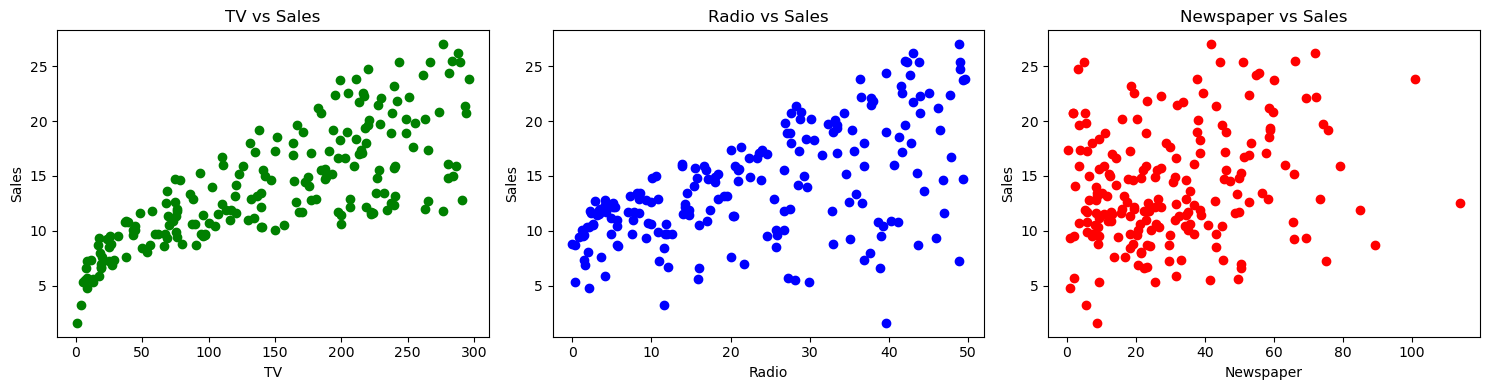

In [5]:
import matplotlib.pyplot as plt

features = ["TV", "Radio", "Newspaper"]
colors = ["green", "blue", "red"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(features):
    axes[i].scatter(data[feature], data["Sales"], color=colors[i])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Sales")
    axes[i].set_title(f"{feature} vs Sales")

plt.tight_layout()
plt.show()

In [6]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


In [7]:
x = data.drop(["Sales"],axis=1)
y = data[["Sales"]]

In [8]:
x

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [9]:
y

,Sales
0,22.1
1,10.4
2,9.3
3,18.5
4,12.9
...,...
195,7.6
196,9.7
197,12.8
198,25.5


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

In [12]:
y_train.shape

(170, 1)

In [13]:
y_test.shape

(30, 1)

In [14]:
from sklearn.linear_model import LinearRegression

In [15]:
mlr = LinearRegression()

In [16]:
mlr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[0.04,0.19,0. ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['TV','Radio','Newspaper']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [17]:
mlr.coef_

array([[0.04481159, 0.18846874, 0.00075285]])

In [18]:
mlr.intercept_

array([3.02802557])

In [19]:
y_train_pred = mlr.predict(x_train)

In [20]:
y_train_pred

array([[12.48735973],
       [10.00637371],
       [21.29657697],
       [12.08873024],
       [18.25420889],
       [20.17061337],
       [14.05685521],
       [20.78464862],
       [11.05449938],
       [ 4.57747821],
       [ 9.69476977],
       [12.71725391],
       [10.01794539],
       [ 8.20827071],
       [13.52989041],
       [ 5.44755186],
       [ 9.23793976],
       [14.14755461],
       [ 8.81548743],
       [11.64208559],
       [15.37860204],
       [11.92206129],
       [12.69047161],
       [10.74708421],
       [ 6.61354797],
       [ 9.92448093],
       [ 9.53087638],
       [24.02071588],
       [ 7.70735281],
       [12.54687748],
       [17.77054651],
       [15.28809419],
       [11.39566983],
       [10.75940701],
       [16.83387484],
       [ 6.92965877],
       [21.4066466 ],
       [ 6.16409071],
       [ 9.97671998],
       [11.53248456],
       [ 9.33911902],
       [ 6.62884104],
       [14.90108566],
       [17.28366765],
       [15.67496433],
       [16

In [21]:
from sklearn.metrics import r2_score,root_mean_squared_error

In [22]:
root_mean_squared_error(y_train,y_train_pred)

1.667621138586194

In [23]:
r2_score(y_train,y_train_pred)

0.8936793584593188

In [24]:
y_test_predict= mlr.predict(x_test)

In [25]:
root_mean_squared_error(y_test,y_test_predict)

1.68940616543273

In [26]:
r2_score(y_test,y_test_predict)

0.9110275702091712

In [27]:
def predict_sales(data):
    return mlr.predict(data)

In [28]:
predict_sales([[150.0, 25.0, 40.0]])

array([[14.4915961]])

In [29]:
tv = float(input("Enter TV Budge:"))
radio = float(input("Enter Radio Budge:"))
newspapetr = float(input("Enter newspaper Budge:"))
predict_sales([[tv,radio,newspapetr]])

Enter TV Budge: 150
Enter Radio Budge: 25
Enter newspaper Budge: 40


array([[14.4915961]])